<a href="https://colab.research.google.com/github/Fatima-05/PSL_TO_SUB/blob/main/psl_to_sub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mediapipe -q

import os, sqlite3, zipfile, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from google.colab import files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.8 MB/s eta 0:00:00


In [ ]:
uploaded=files.upload()

zip_filename=list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall("psl_dataset")
print("fetching:", os.listdir("psl_dataset"))

Saving archive (1).zip to archive (1).zip
Extracted: ['main_dataset.db', 'PSL_dataset']


In [ ]:
db_path="psl_dataset/main_dataset.db"
conn=sqlite3.connect(db_path)
df=pd.read_sql("SELECT * FROM rightHandDataset",conn)
conn.close()

print("shape:",df.shape)
print("columns:",df.columns.tolist())
print("classes:",df['label'].nunique())
print(df['label'].value_counts().sort_index())

Shape: (5112, 44)
Columns: ['id', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6', 'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12', 'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'x17', 'y17', 'x18', 'y18', 'x19', 'y19', 'x20', 'y20', 'x21', 'y21', 'label']
Classes: 37
label
ء‬     87
ا     246
ب     177
ت‬    216
ث‬     99
ج‬    156
ح‬    117
خ‬    216
د‬    159
ذ‬    111
ر‬    162
ز‬     84
س‬    195
ش‬    114
ص‬     84
ض‬     45
ط‬     84
ظ‬     30
ع‬    102
غ‬     48
ف‬     39
ق‬    279
ل‬     63
م‬    252
ن‬     57
و‬    411
ٹ‬    162
پ     144
چ‬    153
ڈ‬    141
ڑ‬     51
ژ‬     87
ک‬     33
گ‬     81
ہ‬    120
ی‬    279
ے‬    228
Name: count, dtype: int64


In [ ]:
feature_cols=[c for c in df.columns if c not in ['id', 'label']]
print(f"feature columns({len(feature_cols)}):{feature_cols}")

X_raw=df[feature_cols].values.astype(np.float32)
y_raw=df['label'].values

Feature columns (42): ['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6', 'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12', 'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'x17', 'y17', 'x18', 'y18', 'x19', 'y19', 'x20', 'y20', 'x21', 'y21']


In [ ]:
def normalise_sample(row):
    coords=row.reshape(21, 2).copy()
    coords-=coords[0]
    spread=np.max(np.abs(coords))
    if spread>0:
        coords=coords/spread*150.0
    coords+=150.0
    return coords.flatten()

X_norm=np.array([normalise_sample(r) for r in X_raw],dtype=np.float32)


In [ ]:
class_names=sorted(list(set(y_raw)),
                     key=lambda c:[
    'ء','ا','ب','ت','ث','ج','ح','خ','د','ذ',
    'ر','ز','س','ش','ص','ض','ط','ظ','ع','غ',
    'ف','ق','ل','م','ن','و','ٹ','پ','چ','ڈ',
    'ڑ','ژ','ک','گ','ہ','ی','ے'
].index(c.strip()) if c.strip() in [
    'ء','ا','ب','ت','ث','ج','ح','خ','د','ذ',
    'ر','ز','س','ش','ص','ض','ط','ظ','ع','غ',
    'ف','ق','ل','م','ن','و','ٹ','پ','چ','ڈ',
    'ڑ','ژ','ک','گ','ہ','ی','ے'
] else 99)

print(f"class order ({len(class_names)}):")
for i, c in enumerate(class_names):
    print(f"  {i:2d}: {c}")

label_to_id={label.strip(): idx for idx, label in enumerate(class_names)}
y_ids=np.array([label_to_id[lbl.strip()] for lbl in y_raw],dtype=np.int32)


Class order (37):
   0: ا
   1: ب
   2: پ
   3: ش‬
   4: ز‬
   5: د‬
   6: ک‬
   7: ظ‬
   8: ض‬
   9: ق‬
  10: خ‬
  11: ع‬
  12: س‬
  13: ص‬
  14: ے‬
  15: م‬
  16: گ‬
  17: ف‬
  18: ڈ‬
  19: ہ‬
  20: و‬
  21: ر‬
  22: ت‬
  23: ٹ‬
  24: غ‬
  25: ی‬
  26: ح‬
  27: ذ‬
  28: ڑ‬
  29: ث‬
  30: ط‬
  31: ج‬
  32: ژ‬
  33: ء‬
  34: چ‬
  35: ل‬
  36: ن‬


In [ ]:
print("class distribution before balancing:")
unique, counts=np.unique(y_ids,return_counts=True)
for u, c in zip(unique,counts):
    print(f"{class_names[u]}: {c}")

max_count=int(np.max(counts))
X_balanced=[]
y_balanced=[]

for cls_id in unique:
    mask = y_ids==cls_id
    X_cls = X_norm[mask]
    y_cls = y_ids[mask]
    n =len(X_cls)
    if n < max_count:
        extra_n = max_count-n
        idx =np.random.choice(n,extra_n,replace=True)
        X_extra = X_cls[idx]+np.random.normal(0,2.0,
                        (extra_n,42)).astype(np.float32)
        X_cls = np.vstack([X_cls,X_extra])
        y_cls = np.concatenate([y_cls,np.full(extra_n,cls_id)])
    X_balanced.append(X_cls)
    y_balanced.append(y_cls)

X_bal= np.vstack(X_balanced).astype(np.float32)
y_bal= np.concatenate(y_balanced).astype(np.int32)

perm=np.random.permutation(len(X_bal))
X_bal=X_bal[perm]
y_bal=y_bal[perm]

print(f"class distribution after balancing:{X_bal.shape[0]}")



Class distribution before balancing:
  ا: 246
  ب: 177
  پ: 144
  ش‬: 114
  ز‬: 84
  د‬: 159
  ک‬: 33
  ظ‬: 30
  ض‬: 45
  ق‬: 279
  خ‬: 216
  ع‬: 102
  س‬: 195
  ص‬: 84
  ے‬: 228
  م‬: 252
  گ‬: 81
  ف‬: 39
  ڈ‬: 141
  ہ‬: 120
  و‬: 411
  ر‬: 162
  ت‬: 216
  ٹ‬: 162
  غ‬: 48
  ی‬: 279
  ح‬: 117
  ذ‬: 111
  ڑ‬: 51
  ث‬: 99
  ط‬: 84
  ج‬: 156
  ژ‬: 87
  ء‬: 87
  چ‬: 153
  ل‬: 63
  ن‬: 57

After balancing: 15207 samples


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

num_classes=len(class_names)
y_train_cat=to_categorical(y_train,num_classes)
y_val_cat=to_categorical(y_val,num_classes)

print(f"train: {X_train.shape}, val: {X_val.shape}")

Train: (12165, 42)  Val: (3042, 42)


In [ ]:
model=Sequential([
    Dense(256,activation='relu',input_shape=(42,)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256,activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64,activation='relu'),
    Dropout(0.2),

    Dense(num_classes,activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,941 (546.64 KB)

 Trainable params: 138,405 (540.64 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [ ]:
callbacks=[
    EarlyStopping(monitor='val_accuracy',patience=15,
                  restore_best_weights=True,verbose=1),
    ReduceLROnPlateau(monitor='val_loss',factor=0.5,
                     patience=5,min_lr=1e-5,verbose=1),
]

history=model.fit(
    X_train,y_train_cat,
    validation_data=(X_val,y_val_cat),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.3510 - loss: 2.3090 - val_accuracy: 0.8767 - val_loss: 0.5688 - learning_rate: 0.0010
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7479 - loss: 0.7660 - val_accuracy: 0.9464 - val_loss: 0.1930 - learning_rate: 0.0010
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8432 - loss: 0.4700 - val_accuracy: 0.9829 - val_loss: 0.0763 - learning_rate: 0.0010
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8807 - loss: 0.3520 - val_accuracy: 0.9750 - val_loss: 0.0727 - learning_rate: 0.0010
Epoch 5/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8878 - loss: 0.3354 - val_accuracy: 0.9882 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 6/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9121 - loss: 0.2619 - val_accuracy: 0.9869 - val_loss: 0.0404 - learning_rate: 0.0010
Epoch 7/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9124 - los

In [ ]:
val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
print(f"validation Accuracy: {val_acc*100:.2f}%")
print(f"validation Loss: {val_loss:.4f}")


Validation Accuracy : 99.97%
   Validation Loss     : 0.0039


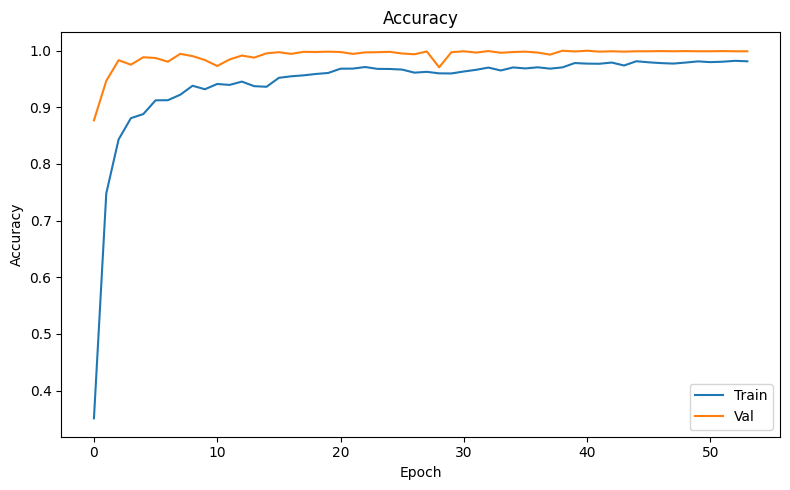

In [ ]:
fig,ax1=plt.subplots(figsize=(8,5))
ax1.plot(history.history['accuracy'],label='Train')
ax1.plot(history.history['val_accuracy'],label='Val')
ax1.set_title('accuracy')
ax1.set_xlabel('epoch')
ax1.set_ylabel('accuracy')
ax1.legend()
plt.tight_layout()
plt.show()

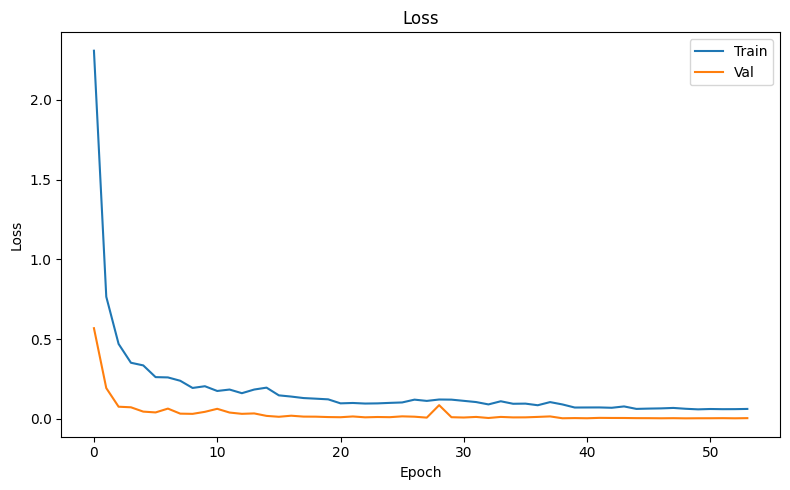

In [ ]:
fig,ax2=plt.subplots(figsize=(8,5))
ax2.plot(history.history['loss'],label='Train')
ax2.plot(history.history['val_loss'],label='Val')
ax2.set_title('loss')
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.legend()
plt.tight_layout()
plt.show()

In [ ]:
model.save("psl_alphabet_model.h5")

with open("class_names.txt","w",encoding="utf-8") as f:
    for name in class_names:
        f.write(name +"\n")
